# Machine learning for segmentation

**Duration** ~50 min &nbsp;·&nbsp; **Session** Day 2, Python notebooks

Day 1 ended in a stalemate. The nuclei segmented fine with a threshold. The
cell channel did not, and no amount of parameter-tuning fixed it, because a
threshold can only ask *is this pixel bright enough?*, and for that channel the
answer does not separate cell from background.

Weka took a different route: examples were painted by hand, and it learned a rule
that is hard to write down explicitly. This notebook picks those results back up in Python, looks
at what a pixel classifier can and cannot do, and then try a model that was
trained by someone else on a hundred thousand cells.

**This notebook covers**

- loading and interpreting a Weka probability map
- what a *pixel* classifier fundamentally cannot do
- running Cellpose, and tuning its one important parameter
- when deep learning is worth the trouble, and when it is not

**Data**: `data/bbbc020/`, and the exports from the Fiji practical in
`data/bbbc020/weka/`.

## 1. The Fiji classifier, in Python

In [1]:
import numpy as np
import tifffile
import matplotlib.pyplot as plt

from skimage.measure import label
from skimage.color import label2rgb

from course import DATA, show

FIELD = "24h_2"

image = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_cells.tif")
truth = tifffile.imread(DATA / "bbbc020" / "gt" / f"{FIELD}_cells_labels.tif")

# If you exported your own in E4, point this at results/weka/ instead.
weka_dir = DATA / "bbbc020" / "weka"
probability = tifffile.imread(weka_dir / f"{FIELD}_cells_probability.tif")
classified = tifffile.imread(weka_dir / f"{FIELD}_cells_classified.tif")

print("image        :", image.shape, image.dtype)
print("probability  :", probability.shape, probability.dtype, f"range {probability.min():.2f}-{probability.max():.2f}")
print("classified   :", classified.shape, classified.dtype, "values", np.unique(classified))

image        : (348, 512) uint8
probability  : (2, 348, 512) float32 range 0.00-1.00
classified   : (348, 512) uint8 values [0 1]


The probability map has an **extra first axis of length 2**: one map per class.
Weka reports, for every pixel, its confidence that the pixel belongs to each
class. The classified image is just that, argmaxed: whichever class won.

Now the question that trips everyone up: **which index is which class?**

In [2]:
# Do NOT assume index 0 is the class you care about. Check it against something
# you already know - here, that stained cells are brighter than background.
for i in range(probability.shape[0]):
    predicted = probability[i] > 0.5
    print(f"probability[{i}]: covers {predicted.mean():5.1%} of pixels, "
          f"mean image intensity there = {image[predicted].mean():5.1f}")
print()
print(f"whole-image mean intensity = {image.mean():.1f}")

probability[0]: covers 29.7% of pixels, mean image intensity there =   9.9
probability[1]: covers 70.3% of pixels, mean image intensity there =  72.2

whole-image mean intensity = 53.6


Index **1** sits on the bright pixels, so that is the cell class. Assuming index 0
would invert every result from here on, and would still produce perfectly
reasonable-looking plots, which is the dangerous part.

Class order comes from the order the classes were created in Fiji, and nothing in
the file records which is which. **It has to be checked against something already known.**

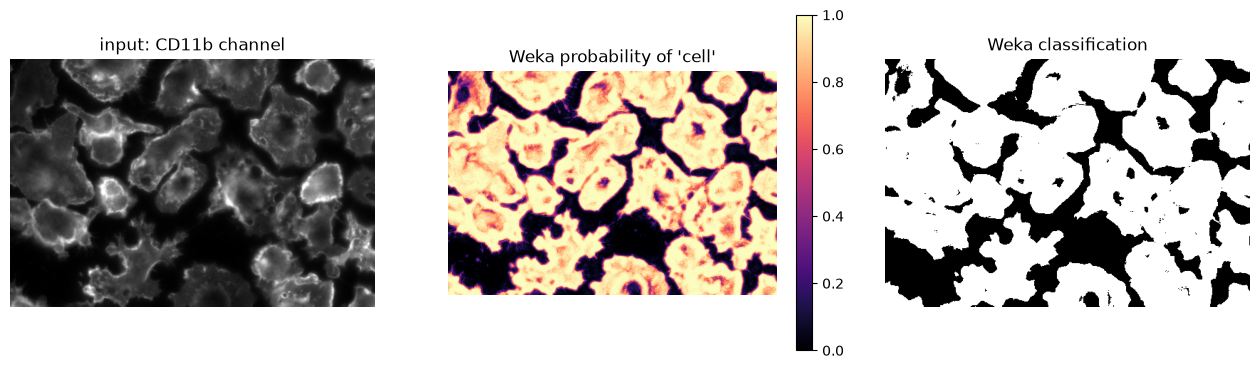

In [3]:
CELL = 1

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show(image, title="input: CD11b channel", ax=axes[0])
im1 = axes[1].imshow(probability[CELL], cmap="magma", vmin=0, vmax=1)
axes[1].set_axis_off(); axes[1].set_title("Weka probability of 'cell'")
plt.colorbar(im1, ax=axes[1], fraction=0.046)
show(classified == CELL, title="Weka classification", ax=axes[2])
plt.show()

The probability map is the more informative of the two. Bright means "confident
this is cell", dark means "confident this is background", and the mid-gray band
around every cell edge is the classifier reporting that *it is not sure*, which is
honest, and which a plain threshold could never express.

The classified image throws that away by taking whichever class scored above
0.5. Keeping the probability leaves the cut-off open to be chosen later.

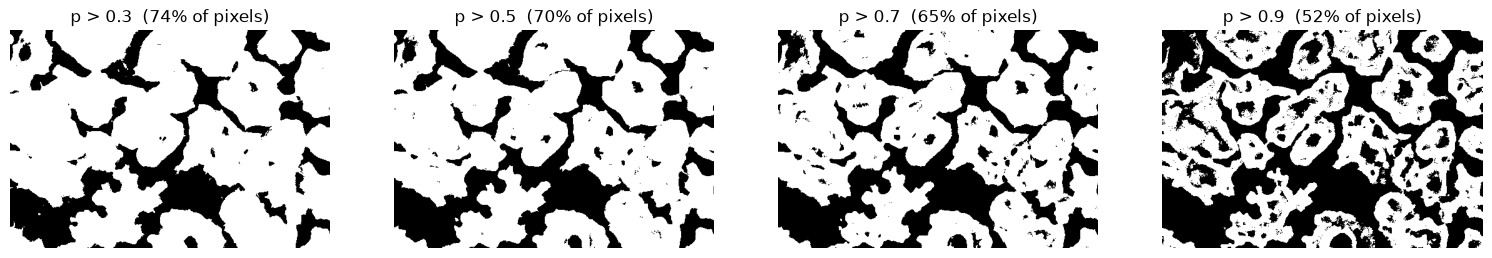

In [4]:
# The cut-off is yours to choose. It is not automatically 0.5.
fig, axes = plt.subplots(1, 4, figsize=(19, 4))
for ax, t in zip(axes, [0.3, 0.5, 0.7, 0.9]):
    mask = probability[CELL] > t
    show(mask, title=f"p > {t}  ({mask.mean():.0%} of pixels)", ax=ax)
plt.show()

## 2. Semantic and instance segmentation

In [5]:
weka_mask = classified == CELL
weka_labels = label(weka_mask)

print("annotated cells    :", truth.max())
print("Weka objects       :", weka_labels.max())

annotated cells    : 23
Weka objects       : 16


Twenty-three cells in the annotation. **Sixteen** objects from Weka.

This is worth naming properly, because the distinction runs through the rest of
the course:

- **Semantic segmentation** answers *"what kind of thing is this pixel?"*. Weka
  gives exactly this: every pixel is labeled cell or background, and that
  is all.
- **Instance segmentation** answers *"which object is this pixel part of?"*: 
  cell number 7 rather than merely "a cell".

Weka is a *pixel* classifier. It considers each pixel more or less on its own, so
it has no concept of an object at all. When two cells touch, every pixel in both
is correctly labeled "cell", and connected-component labeling then quite
reasonably calls the result one object. The classifier did its job; its job is
just not the one needed here.

The tool for turning semantic into instance has already appeared: the
**watershed** from `02_image_processing`.

In [6]:
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed

distance = distance_transform_edt(weka_mask)
print("largest distance-to-edge:", round(distance.max(), 1), "px")

# Same recipe as notebook 02: seeds are the cores of the mask, and the cut-off
# is roughly the minimum object radius we insist on. These cells are far larger
# than nuclei, so the cut-off has to be far larger too.
for t in [5, 10, 15, 20, 25]:
    print(f"distance > {t:2d}  ->  {label(distance > t).max():2d} seed(s)")

largest distance-to-edge: 59.2 px
distance >  5  ->  17 seed(s)
distance > 10  ->  29 seed(s)
distance > 15  ->  40 seed(s)
distance > 20  ->  30 seed(s)
distance > 25  ->  15 seed(s)


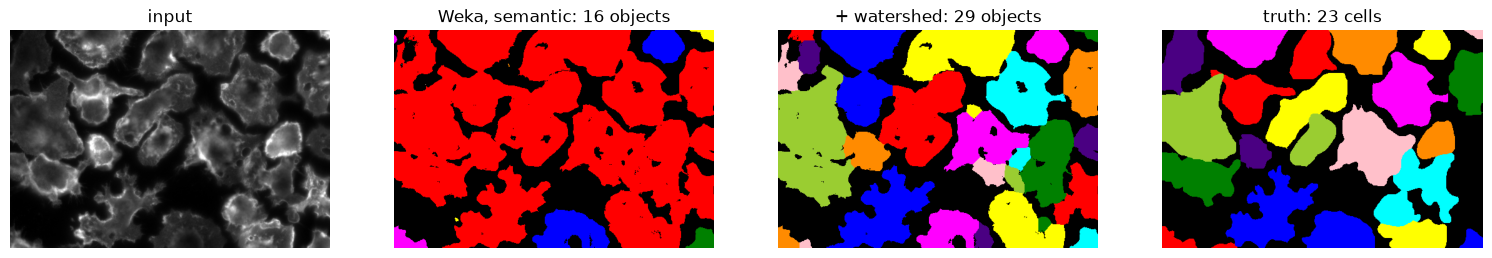

In [7]:
seeds = label(distance > 10)
weka_instances = watershed(-distance, seeds, mask=weka_mask)

fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(image, title="input", ax=axes[0])
axes[1].imshow(label2rgb(weka_labels, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"Weka, semantic: {weka_labels.max()} objects")
axes[2].imshow(label2rgb(weka_instances, bg_label=0)); axes[2].set_axis_off()
axes[2].set_title(f"+ watershed: {weka_instances.max()} objects")
axes[3].imshow(label2rgb(truth, bg_label=0)); axes[3].set_axis_off()
axes[3].set_title(f"truth: {truth.max()} cells")
plt.show()

The watershed pulls the merged blobs apart, and promptly overshoots, landing
above the annotation rather than below it.

Notice how sensitive it is. For the nuclei in notebook 02 any cut-off from 5 to 8
gave the same answer; here the count swings between 15 and 40 as the cut-off
moves, and not even monotonically. **There is no plateau to sit on**, which means
any value chosen here is a choice rather than something the data supports.

That is the honest state of this pipeline. A pixel classifier plus a
hand-tuned watershed can be pushed to roughly the right number, but the
"roughly" is doing a lot of work and the parameter has no obviously correct
value.

Which raises the question: is there a method that produces instances *directly*?

```{admonition} Shallow vs deep, in one paragraph
Weka is *shallow* learning: **the features are chosen by hand** (Gaussian blur, edges,
texture at various scales) and it learns how to weigh them. A *deep* network
learns the features too, from data, which is why it needs a great deal of data,
and why using one someone else already trained is usually the sensible move.
```

## 3. Cellpose

[Cellpose](https://www.cellpose.org) is a deep model trained on a large, varied
collection of cell images. Two things make it practical here:

1. **It outputs instances**, not a pixel mask: touching cells come out separated.
2. **It generalises.** It runs below on images it has never seen, with no
   additional training.

In [8]:
from cellpose import models

# `cyto` is the general cell model; there is also a `nuclei` model.
model = models.Cellpose(model_type="cyto", gpu=False)

In [9]:
# diameter=None asks Cellpose to estimate object size itself.
masks, flows, styles, diameter = model.eval(image, diameter=None, channels=[0, 0])

print(f"estimated diameter : {diameter:.0f} px")
print(f"objects found      : {masks.max()}")
print(f"annotated          : {truth.max()}")

estimated diameter : 65 px
objects found      : 28
annotated          : 23


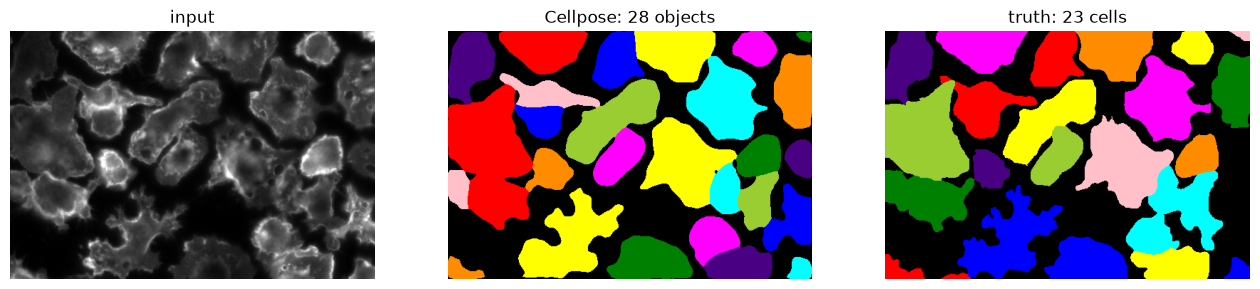

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
show(image, title="input", ax=axes[0])
axes[1].imshow(label2rgb(masks, bg_label=0)); axes[1].set_axis_off()
axes[1].set_title(f"Cellpose: {masks.max()} objects")
axes[2].imshow(label2rgb(truth, bg_label=0)); axes[2].set_axis_off()
axes[2].set_title(f"truth: {truth.max()} cells")
plt.show()

The cells are separated: that is the thing Weka could not do.

But look at the count. Cellpose found considerably more objects than the
annotation has, and the reason *why* matters. Two possibilities, and they call
for opposite responses:

1. Cellpose is over-segmenting, splitting single cells in two.
2. Cellpose is finding real cells that the annotator did not outline.

**Both are happening here.** The BBBC020 cell annotations are known to be
incomplete: on this field about 83% of the nuclei have a corresponding cell
outline, and the rest of the cells are simply unlabelled. So some of that excess
is real.

This is worth internalising: **"more objects than the ground truth" is not
automatically an error.** It might be the ground truth.

## 4. The one parameter that matters

In [11]:
for d in [None, 20, 40, 80]:
    m, _, _, est = model.eval(image, diameter=d, channels=[0, 0])
    label_txt = f"auto ({est:.0f})" if d is None else str(d)
    print(f"diameter = {label_txt:>10}  ->  {m.max():3d} objects")

diameter =  auto (65)  ->   28 objects


diameter =         20  ->   36 objects


diameter =         40  ->   30 objects


diameter =         80  ->   27 objects


`diameter` tells Cellpose how big it should expect objects to be, and it rescales
the image accordingly. Get it badly wrong and results collapse: too small and
cells shatter into fragments, too large and neighbours merge.

The automatic estimate is usually decent, but it is an estimate. **If a Cellpose
result looks wrong, this is the first thing to check**, and it can be checked
directly by measuring a few cells in Fiji and seeing whether the number is
plausible.

## 5. Three methods, side by side

In [12]:
from skimage.filters import threshold_otsu, gaussian
from skimage.morphology import remove_small_objects
from scipy.ndimage import binary_fill_holes


def classical(img, sigma=1, max_size=100, seed_distance=15):
    """Yesterday's pipeline: smooth, threshold, clean, split."""
    smoothed = gaussian(img, sigma=sigma, preserve_range=True)
    mask = binary_fill_holes(smoothed > threshold_otsu(smoothed))
    mask = remove_small_objects(mask, max_size=max_size)
    d = distance_transform_edt(mask)
    return watershed(-d, label(d > seed_distance), mask=mask)


threshold_labels = classical(image)

print(f"{'method':22s} {'objects':>8s}   (truth: {truth.max()})")
print("-" * 34)
print(f"{'threshold + watershed':22s} {threshold_labels.max():8d}")
print(f"{'Weka + watershed':22s} {weka_instances.max():8d}")
print(f"{'Cellpose':22s} {masks.max():8d}")

method                  objects   (truth: 23)
----------------------------------
threshold + watershed        19
Weka + watershed             29
Cellpose                     28


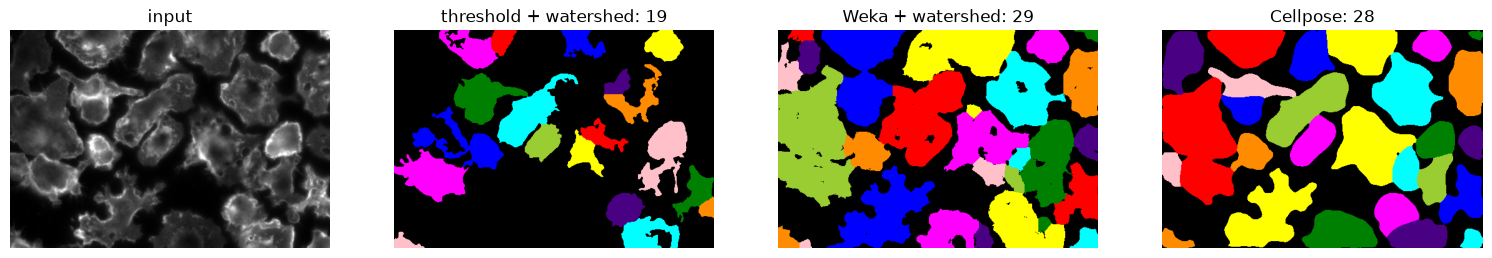

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.5))
show(image, title="input", ax=axes[0])
for ax, (name, result) in zip(axes[1:], [
    ("threshold + watershed", threshold_labels),
    ("Weka + watershed", weka_instances),
    ("Cellpose", masks),
]):
    ax.imshow(label2rgb(result, bg_label=0)); ax.set_axis_off()
    ax.set_title(f"{name}: {result.max()}")
plt.show()

Three plausible-looking results and three different counts, none of them equal to
the annotation.

**So which is best?** The pictures support an opinion: Cellpose separates
neighbours more convincingly, and the threshold result is speckled. But an
opinion is not a measurement, and the object counts alone are clearly not enough
either. The count would happily call a method perfect that found the right
*number* of completely wrong objects.

This is where eyeballing finally runs out, and it is exactly what the next
notebook is for. `04_segmentation_metrics` introduces the measures that answer
this question properly, and then puts these same three results through them. Some
of the answers are surprising.

## 6. Does the hard channel need all this?

In [14]:
# The nuclei, for comparison - the channel that thresholded fine yesterday.
nuclei = tifffile.imread(DATA / "bbbc020" / "images" / f"{FIELD}_nuclei.tif")
nuclei_truth = tifffile.imread(DATA / "bbbc020" / "gt" / f"{FIELD}_nuclei_labels.tif")

nuclei_model = models.Cellpose(model_type="nuclei", gpu=False)
nuclei_masks, _, _, _ = nuclei_model.eval(nuclei, diameter=None, channels=[0, 0])
nuclei_classical = classical(nuclei, sigma=1, max_size=40, seed_distance=5)

print(f"{'':22s} {'threshold':>10s} {'Cellpose':>10s} {'truth':>7s}")
print("-" * 52)
print(f"{'nuclei channel':22s} {nuclei_classical.max():10d} {nuclei_masks.max():10d} {nuclei_truth.max():7d}")
print(f"{'cells channel':22s} {threshold_labels.max():10d} {masks.max():10d} {truth.max():7d}")

                        threshold   Cellpose   truth
----------------------------------------------------
nuclei channel                 21         21      22
cells channel                  19         28      23


On the nuclei the two methods land in much the same place. On the cells they do
not.

That is the shape of the answer, and it is worth carrying forward even before we
can put a number on it:

- The nuclei are compact, bright and well separated. The problem is easy, so a
  simple method already solves most of it and a complicated one has little left
  to add.
- The cells touch, fade at the edges and vary in brightness. The problem is hard,
  and that is where the learned methods earn their place.

**Reach for the simple thing first.** Six lines of scikit-image run instantly,
are easy to explain in a paper, and have no model weights to go stale. Move up
when it visibly fails, and day 1 showed exactly what that looks like.

The corollary matters just as much: **do not assume the fancy method is better,
measure it.** The next notebook does precisely that, on these three
results.

## Recap

| | learns | outputs | separates touching objects |
|---|---|---|---|
| threshold | nothing | pixels | no (needs a watershed) |
| Weka | weights on hand-chosen features | pixels | **no, structurally** |
| Cellpose | features and weights, from data | **objects** | yes |

Note what this notebook deliberately did **not** do: put a number on which
result is best. Counting objects is not enough, and every comparison here was
either a count or a picture.

Next: `04_segmentation_metrics`, which supplies the missing measures and applies
them to exactly these three results.